In [4]:
#%pip install opencv-python --break-system-packages
#%pip install matplotlib --break-system-packages
#%pip install --upgrade numpy opencv-python matplotlib --break-system-packages
#%pip install pandas --break-system-packages

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 804.8 kB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 24.8 MB/s eta 0:00:0000:010:01
Note: you may need to restart the kernel to use updated packages.


In [15]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

img_bgr = cv2.imread('mountain.jpg')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

gray_image = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
gray_vector = gray_image.flatten()


nb_lignes, nb_colonnes, nb_couleur = img_rgb.shape


In [ ]:
# Calcul de la matrice A
ax, ay = np.gradient(gray_image)

Ax = np.eye()*ax.flatten()
Ay = np.eye()*ay.flatten()

MemoryError: Unable to allocate 8.65 TiB for an array with shape (1090560, 1090560) and data type float64

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5..1.499985863618564].


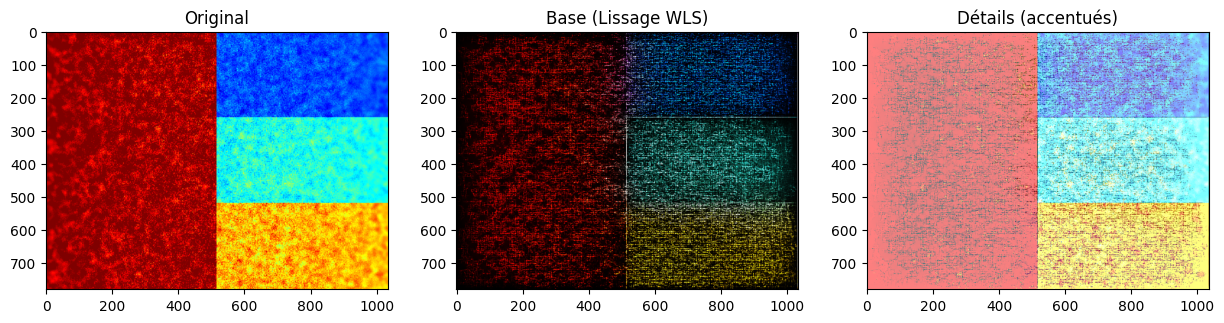

In [3]:
import numpy as np
import cv2
from scipy import sparse
from scipy.sparse.linalg import spsolve

def wls_filter(img, lamb=1.0, alpha=1.2, eps=1e-4):
    """
    Arguments:
        img   : Image d'entrée (0 à 1, float).
        lamb  : Paramètre de lissage (lambda). Plus il est grand, plus c'est lisse.
        alpha : Contrôle la sensibilité aux gradients (typiquement 1.2 à 2.0).
        eps   : Petite valeur pour éviter la division par zéro.
    """

    L = img.astype(np.float64)
    if len(L.shape) == 3:
        gray = cv2.cvtColor((L * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY) / 255.0
    else:
        gray = L

    r, c = gray.shape
    k = r * c

    # 1. Calcul des gradients logarithmiques (pour la sensibilité aux bords)
    # On calcule les différences horizontales et verticales
    dy = np.diff(gray, axis=0)
    dx = np.diff(gray, axis=1)

    # Padding pour garder la même taille que l'image d'origine
    dy = -lamb / (np.abs(dy)**alpha + eps)
    dx = -lamb / (np.abs(dx)**alpha + eps)
    
    dy = np.pad(dy, ((0, 1), (0, 0)), 'constant')
    dx = np.pad(dx, ((0, 0), (0, 1)), 'constant')

    # Construction des vecteurs pour la matrice diagonale
    dy = dy.flatten()
    dx = dx.flatten()

    # 2. Construction de la matrice de lissage (Laplacienne inhomogène)
    # On crée une matrice creuse à 5 diagonales
    # La diagonale principale contient 1 - (somme des poids adjacents)
    w = np.pad(dx[:-1], (1, 0), 'constant') # poids gauche
    n = np.pad(dy[:-c], (c, 0), 'constant') # poids haut
    
    # Diagonale principale (I + lambda * Lg)
    # Note: On soustrait les poids car dx et dy sont déjà multipliés par -lambda
    d = 1 - (dx + w + dy + n)

    data = np.stack([n, w, d, dx, dy])
    diags = np.array([-c, -1, 0, 1, c])
    A = sparse.spdiags(data, diags, k, k).tocsr()

    # 3. Résolution du système pour chaque canal
    out = np.zeros_like(L)
    if len(L.shape) == 3:
        for i in range(3):
            out[:, :, i] = spsolve(A, L[:, :, i].flatten()).reshape(r, c)
    else:
        out = spsolve(A, L.flatten()).reshape(r, c)

    return np.clip(out, 0, 1)


# Charger l'image et normaliser entre 0 et 1
image = cv2.imread('photo_de_test.png')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) / 255.0

# Extraire la couche de base (base layer)
# Pour l'abstraction d'image, on utilise souvent un lambda élevé et alpha=2.0
base = wls_filter(image, lamb=2.0, alpha=2.0)

# Extraire les détails (detail layer)
detail = image - base

# Affichage (exemple avec Matplotlib)
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 5))
plt.subplot(131), plt.imshow(image), plt.title('Original')
plt.subplot(132), plt.imshow(base), plt.title('Base (Lissage WLS)')
plt.subplot(133), plt.imshow(detail + 0.5), plt.title('Détails (accentués)')
plt.show()